# Question 3
## Data Visualisation: South Africa GDP Growth and Employment

## Introduction

This notebook presents visualisations of two South African datasets: GDP growth and employment by economic sector for the period 1961 to 2017. The purpose of the visualisation analysis is to identify trends, patterns and differences in South Africa's economic performance and employment over time.

The analysis uses the cleaned dataset prepared for the group assignment. GDP growth represents annual changes in South Africa's economic output, while employment data shows the number of people employed across different economic sectors.

The visualisations are designed to examine how GDP growth changed over time, how employment changed over time, how employment differed across sectors, and whether GDP growth and total employment show a clear relationship.

Together, the visualisations help tell one overall story: economic growth and employment are related aspects of the South African economy.

### 1. Import Libraries &  Load Dataset the cleaned dataset

In [49]:
# load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

# Load the clean dataset
try:
    df = pd.read_csv('../../data/final_clean/GDP_Employment_South_Africa_Cleaned.csv')
    print(f" Loaded {len(df)} rows")
except FileNotFoundError:
    print(" File not found!")
    raise

print(f"Country: {df['REF_AREA_LABEL'].unique()}")
print(f"Years: {df['TIME_PERIOD'].min()} to {df['TIME_PERIOD'].max()}")
print(f"Columns: {df.columns.tolist()}")
df.head()

 Loaded 570 rows
Country: <StringArray>
['South Africa']
Length: 1, dtype: str
Years: 1961 to 2017
Columns: ['REF_AREA_LABEL', 'TIME_PERIOD', 'GDP_Growth', 'Employment_Thousands', 'Sector']


,REF_AREA_LABEL,TIME_PERIOD,GDP_Growth,Employment_Thousands,Sector
0,South Africa,2017,1.157947,16536.302734,Sector: Total
1,South Africa,2017,1.157947,849.620773,Sector: Agriculture
2,South Africa,2017,1.157947,414.533398,Sector: Mining
3,South Africa,2017,1.157947,1855.818421,Sector: Manufacturing
4,South Africa,2017,1.157947,187.111598,Sector: Utilities


## 2. Verify the cleaned dataset

In [50]:
print("===== DATASET VERIFICATION =====")

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nCountries:")
print(df['REF_AREA_LABEL'].unique())

print("\nNumber of countries:")
print(df['REF_AREA_LABEL'].nunique())

print("\nYears:")
print(df['TIME_PERIOD'].min(), "to", df['TIME_PERIOD'].max())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nSectors:")
print(df['Sector'].unique())

===== DATASET VERIFICATION =====

Shape:
(570, 5)

Columns:
['REF_AREA_LABEL', 'TIME_PERIOD', 'GDP_Growth', 'Employment_Thousands', 'Sector']

Countries:
<StringArray>
['South Africa']
Length: 1, dtype: str

Number of countries:
1

Years:
1961 to 2017

Missing values:
REF_AREA_LABEL          0
TIME_PERIOD             0
GDP_Growth              0
Employment_Thousands    0
Sector                  0
dtype: int64

Duplicate rows:
0

Sectors:
<StringArray>
[                        'Sector: Total',
                   'Sector: Agriculture',
                        'Sector: Mining',
                 'Sector: Manufacturing',
                     'Sector: Utilities',
                  'Sector: Construction',
                'Sector: Trade services',
            'Sector: Transport services',
 'Sector: Finance and business services',
                'Sector: Other services']
Length: 10, dtype: str


###  3. Prepare Data

In [51]:

# Prepare Data - Filter "Sector: Total"
df_total = df[df['Sector'] == 'Sector: Total'].copy()

# Rename columns for easier use
df_total.rename(columns={
    'TIME_PERIOD': 'Year',
    'GDP_Growth': 'GDP_growth',
    'Employment_Thousands': 'Employment'
}, inplace=True)

df_total = df_total.sort_values('Year')

print(f"Years: {df_total['Year'].min()} to {df_total['Year'].max()}")
print(f"Total rows: {len(df_total)}")
df_total[['Year', 'GDP_growth', 'Employment']].head()

Years: 1961 to 2017
Total rows: 57


,Year,GDP_growth,Employment
560,1961,3.844734,4653.677246
550,1962,6.177931,4716.896973
500,1963,7.373709,4795.137207
250,1964,7.939609,4930.197754
260,1965,6.122798,5064.761230


 ### 4. BAR CHART - GDP Growth (South Africa)

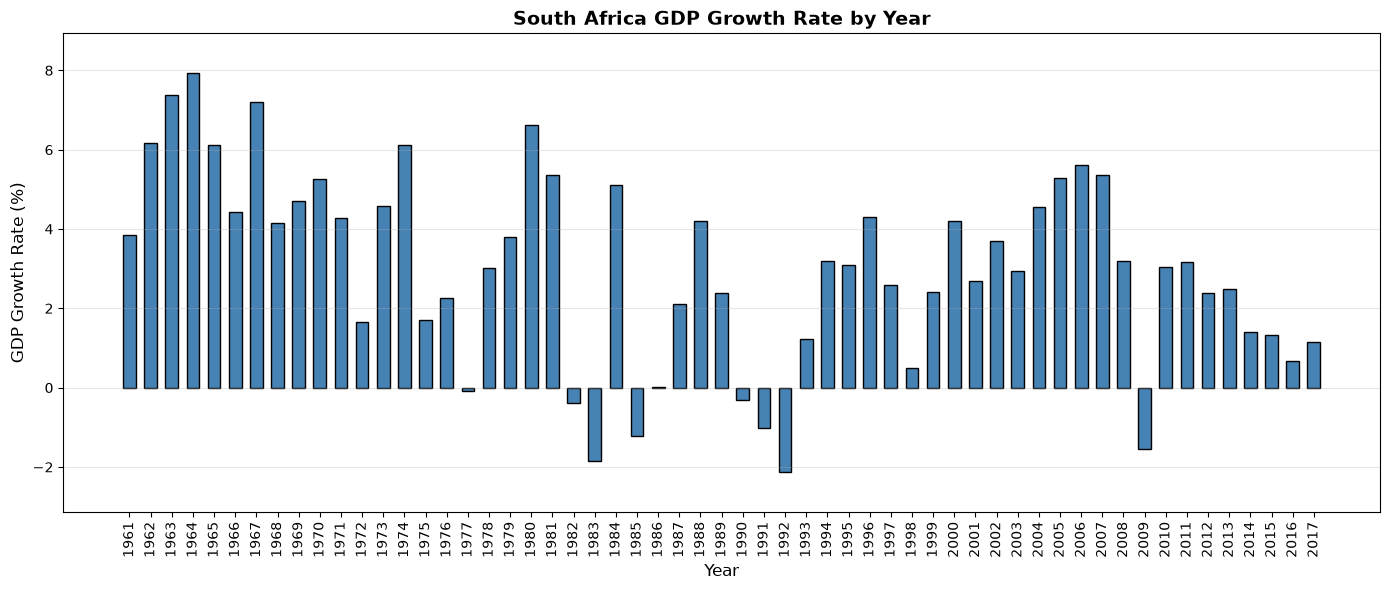

 Bar chart saved as 'bar_gdp_sa.png'


In [52]:
# BAR CHART - GDP Growth (South Africa)

# Use all years
df_all_years = df_total.copy()

plt.figure(figsize=(14, 6))

# Draw bars with proper width
plt.bar(df_all_years['Year'], df_all_years['GDP_growth'], 
        color='steelblue', edgecolor='black', linewidth=1, width=0.6)

plt.title('South Africa GDP Growth Rate by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('GDP Growth Rate (%)', fontsize=12)
plt.ylim(min(df_all_years['GDP_growth']) - 1, max(df_all_years['GDP_growth']) + 1)
plt.grid(axis='y', alpha=0.3)

# Show EVERY year on X-axis
plt.xticks(df_all_years['Year'], rotation=90)

plt.tight_layout()
plt.savefig('bar_gdp_sa.png', dpi=300)
plt.show()

print(" Bar chart saved as 'bar_gdp_sa.png'")

### GDP Growth by Year
A vertical bar chart was used to display South Africa's annual GDP growth rate for every year from 1961 to 2017. Bars extending above the zero line represent years of positive economic growth, while bars extending below the line represent years the economy contracted. This format was chosen because it allows individual years to be compared directly against one another and makes it immediately clear which specific years experienced the strongest growth (such as 1964, at 7.94%) and which experienced the sharpest declines (such as 1992, at -2.14%). The y-axis was adjusted to accommodate both positive and negative values so that no data would be cut off.

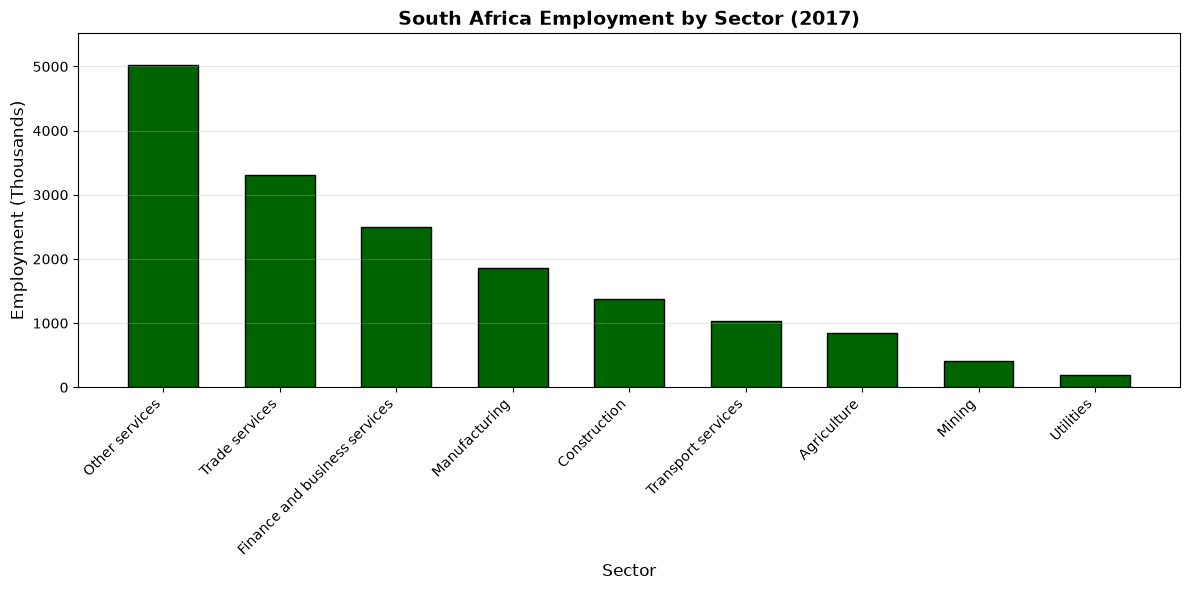

 Vertical bar chart saved as 'bar_sectors_sa.png'


In [53]:
#  BAR CHART - Employment by Sector (VERTICAL BARS)

latest_year = df_total['Year'].max()

# Filter sector data
df_sectors = df[df['TIME_PERIOD'] == latest_year].copy()
df_sectors = df_sectors[df_sectors['Sector'] != 'Sector: Total'].copy()
df_sectors['Sector_Clean'] = df_sectors['Sector'].str.replace('Sector: ', '')
df_sectors = df_sectors.sort_values('Employment_Thousands', ascending=False)

plt.figure(figsize=(12, 6))

# VERTICAL BARS 
plt.bar(df_sectors['Sector_Clean'], df_sectors['Employment_Thousands'],
        color='darkgreen', edgecolor='black', linewidth=1, width=0.6)

plt.title(f'South Africa Employment by Sector ({latest_year})', fontsize=14, fontweight='bold')
plt.xlabel('Sector', fontsize=12)
plt.ylabel('Employment (Thousands)', fontsize=12)
plt.ylim(0, max(df_sectors['Employment_Thousands']) * 1.1)
plt.grid(axis='y', alpha=0.3)

# Rotate labels so they don't overlap
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('bar_sectors_sa.png', dpi=300)
plt.show()

print(" Vertical bar chart saved as 'bar_sectors_sa.png'")

### Employment by Sector
A second bar chart was used to compare total employment across South Africa's nine economic sectors for the most recent year in the dataset (2017). Sectors were sorted from highest to lowest employment so the chart reads clearly from left to right, immediately highlighting Other Services and Trade Services as the largest employers, and Utilities and Mining as the smallest. Starting the axis at zero ensures the bar heights give a fair and accurate visual comparison between sectors.

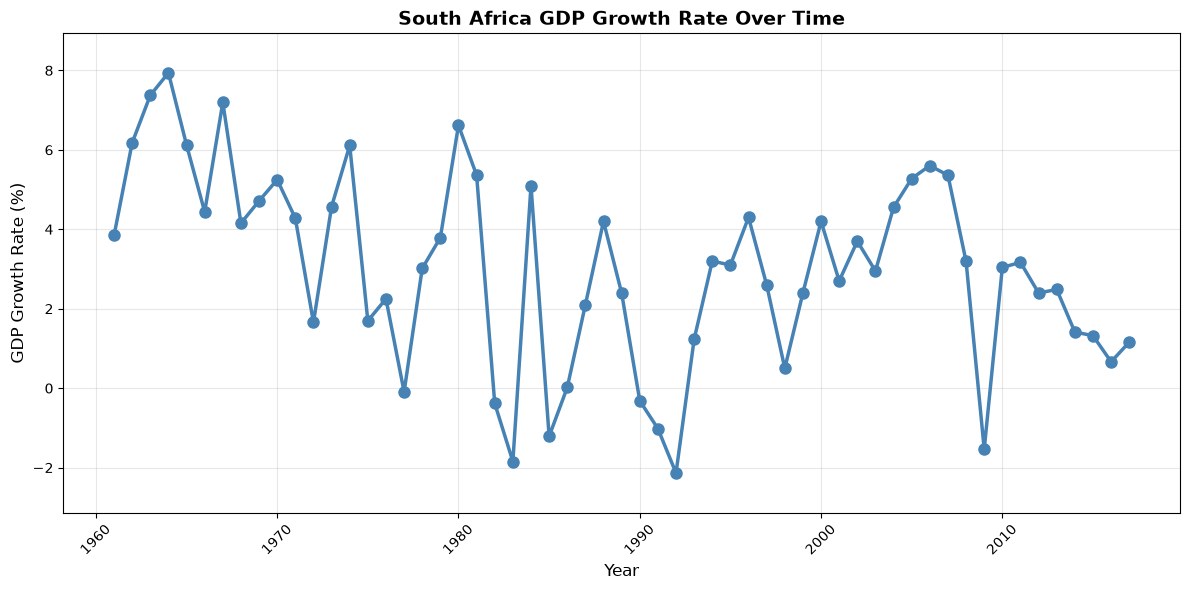

 Line chart saved as 'line_gdp_sa.png'


In [54]:
#  LINE CHART - GDP Trend (Matches Employment Graph Style)

plt.figure(figsize=(12, 6))

# Plot ALL years with line and markers
plt.plot(df_total['Year'], df_total['GDP_growth'], 
         marker='o', linestyle='-', linewidth=2.5, color='steelblue', markersize=8)

plt.title('South Africa GDP Growth Rate Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('GDP Growth Rate (%)', fontsize=12)

# Let Y-axis show negative values (GDP can be negative)
y_min = df_total['GDP_growth'].min() - 1
y_max = df_total['GDP_growth'].max() + 1
plt.ylim(y_min, y_max)

plt.grid(alpha=0.3)

# Rotate x labels 45 degrees (SAME AS EMPLOYMENT)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('line_gdp_sa.png', dpi=300)
plt.show()

print(" Line chart saved as 'line_gdp_sa.png'")

### GDP Growth Over Time
A line chart with markers was used to trace the year-by-year movement of GDP growth across the full 57-year period. Unlike the bar chart, the continuous line makes longer-term movement easier to follow, showing periods of stronger growth alongside more volatile stretches where growth dipped or turned negative. This chart is useful for spotting overall trends and turning points rather than isolated yearly values.

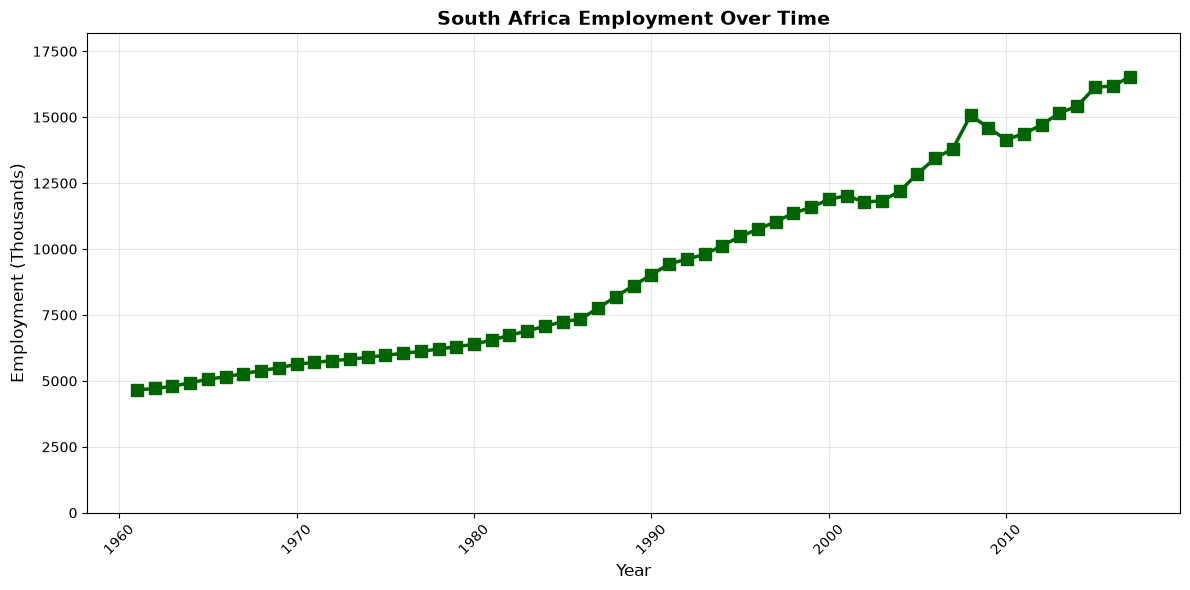

 Employment line chart saved as 'line_employment_sa.png'


In [55]:
# INE CHART - Employment Trend (South Africa)

plt.figure(figsize=(12, 6))
plt.plot(df_total['Year'], df_total['Employment'], 
         marker='s', linestyle='-', linewidth=2.5, color='darkgreen', markersize=8)

plt.title('South Africa Employment Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Employment (Thousands)', fontsize=12)
plt.ylim(0, max(df_total['Employment']) * 1.1)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('line_employment_sa.png', dpi=300)
plt.show()

print(" Employment line chart saved as 'line_employment_sa.png'")

### Employment Over Time
Similarly, a line chart was used to track total employment from 1961 to 2017. The chart shows a broadly upward trend over time, reflecting the long-term growth of South Africa's population and economy across more than five decades, although the rate of increase is not perfectly smooth and includes periods of slower growth.

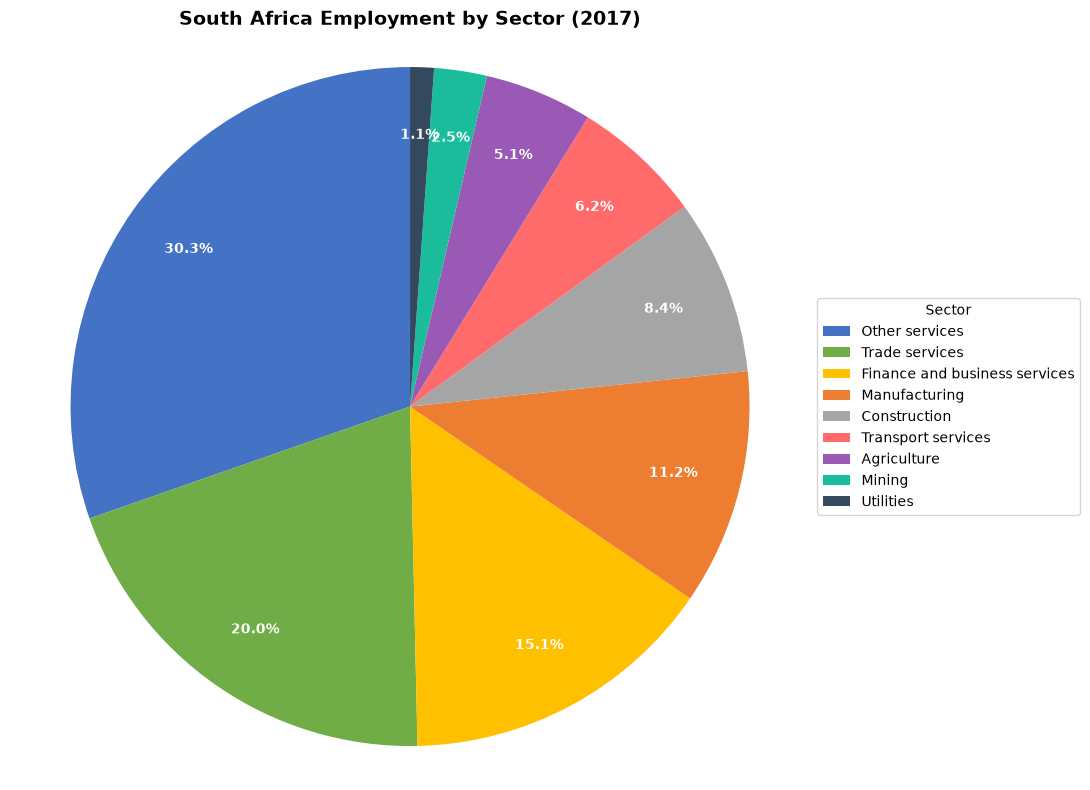

 Pie chart saved as 'pie_sectors_sa.png'


In [56]:
#PIE CHART - Employment by Sector (South Africa)

latest_year = df_total['Year'].max()
df_sectors = df[df['TIME_PERIOD'] == latest_year].copy()
df_sectors = df_sectors[df_sectors['Sector'] != 'Sector: Total'].copy()
df_sectors['Sector_Clean'] = df_sectors['Sector'].str.replace('Sector: ', '')
df_sectors = df_sectors.sort_values('Employment_Thousands', ascending=False)

plt.figure(figsize=(11, 8))

# pie chart with percentages only on slices (no on-slice name labels, to avoid overlap on small slices)
wedges, texts, autotexts = plt.pie(
    df_sectors['Employment_Thousands'],
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
    colors=['#4472C4', '#70AD47', '#FFC000', '#ED7D31', '#A5A5A5', '#FF6B6B', '#9B59B6', '#1ABC9C', '#34495E']
)


for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Sector names shown as a legend on the side instead of on the slices themselves,
# so small slices (like Utilities and Mining) never overlap with their labels
plt.legend(wedges, df_sectors['Sector_Clean'],
           title="Sector",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1),
           fontsize=10)

plt.title(f'South Africa Employment by Sector ({latest_year})', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.savefig('pie_sectors_sa.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Pie chart saved as 'pie_sectors_sa.png'")



### Employment by Sector
A pie chart was used to show each sector's share of total 2017 employment as a percentage of the whole. Other Services accounts for the largest share at 30.3%, followed by Trade Services at 20.0% and Finance and Business Services at 15.1%. At the other end of the scale, Utilities makes up just 1.1% and Mining 2.5% of total employment. A legend was placed alongside the chart rather than labelling each slice directly, so that the smaller slices remain easy to read without their labels overlapping.

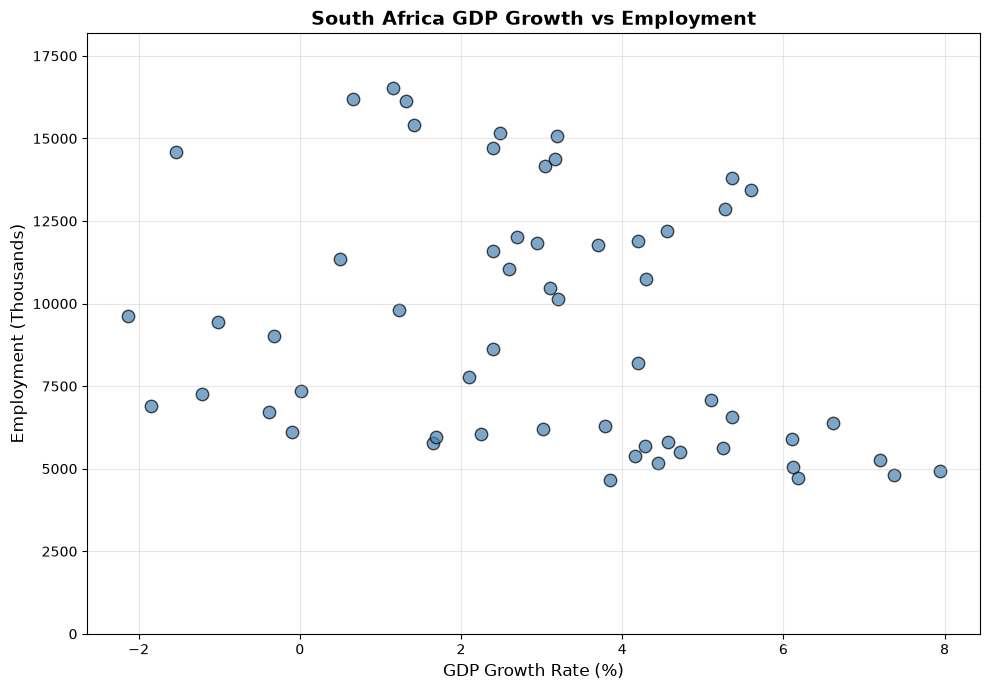

 Scatter plot saved as 'scatter_gdp_employment_sa.png'


In [57]:
# SCATTER PLOT - GDP vs Employment (South Africa)

plt.figure(figsize=(10, 7))
plt.scatter(df_total['GDP_growth'], df_total['Employment'],
            color='steelblue', s=80, alpha=0.7, edgecolors='black')

plt.title('South Africa GDP Growth vs Employment', fontsize=14, fontweight='bold')
plt.xlabel('GDP Growth Rate (%)', fontsize=12)
plt.ylabel('Employment (Thousands)', fontsize=12)
plt.xlim(df_total['GDP_growth'].min() - 0.5, df_total['GDP_growth'].max() + 0.5)
plt.ylim(0, max(df_total['Employment']) * 1.1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_gdp_employment_sa.png', dpi=300)
plt.show()

print(" Scatter plot saved as 'scatter_gdp_employment_sa.png'")

### GDP Growth vs Employment
A scatter plot was used to plot each year's GDP growth rate against that year's total employment figure, with each dot representing one year. This chart is used to visually check whether the two variables move together in any consistent pattern. The points in this dataset appear widely scattered with a slight downward tendency, visually supporting the weak negative correlation coefficient (-0.30) calculated in the numerical analysis.


### 10. Correlation Verification

To confirm the correlation coefficient referenced above, it is calculated here using two methods: NumPy's built-in np.corrcoef() function, and the Pearson correlation formula applied manually. Both approaches produce the same result, confirming the calculation is correct

In [58]:
# Correlation Verification - GDP Growth vs Employment

x = df_total['GDP_growth']
y = df_total['Employment']

x_mean = np.mean(x)
y_mean = np.mean(y)

numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))

correlation = numerator / denominator

print(f"Correlation coefficient (calculated manually): {correlation:.4f}")
print(f"Correlation coefficient (using np.corrcoef):    {np.corrcoef(x, y)[0, 1]:.4f}")

Correlation coefficient (calculated manually): -0.2975
Correlation coefficient (using np.corrcoef):    -0.2975


### 11. Histogram - Distribution of GDP Growth



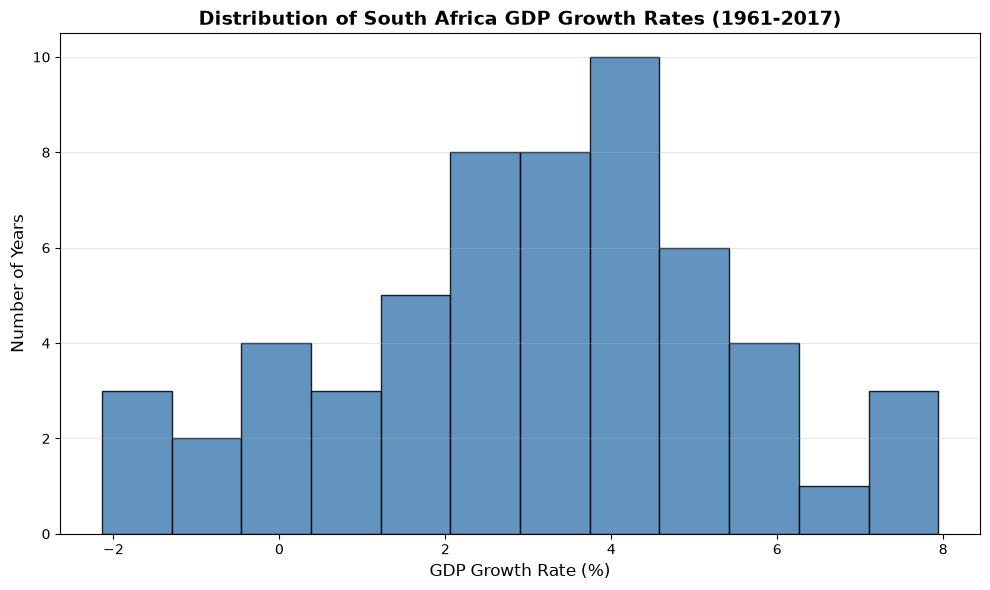

 Histogram saved as 'hist_gdp_sa.png'


In [59]:
# HISTOGRAM - Distribution of GDP Growth (South Africa)

plt.figure(figsize=(10, 6))

plt.hist(df_total['GDP_growth'], bins=12, color='steelblue', edgecolor='black', alpha=0.85)

plt.title('Distribution of South Africa GDP Growth Rates (1961-2017)', fontsize=14, fontweight='bold')
plt.xlabel('GDP Growth Rate (%)', fontsize=12)
plt.ylabel('Number of Years', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hist_gdp_sa.png', dpi=300)
plt.show()

print(" Histogram saved as 'hist_gdp_sa.png'")


### Distribution of GDP Growth
A histogram was used to group all 57 years of GDP growth data into ranges and count how many years fall into each range. This shows that GDP growth most commonly falls between roughly 2% and 5%, with fewer years experiencing very low, negative, or very high growth, indicating that while the economy has had some volatile years, typical annual growth has been moderate and broadly consistent.

### 11. Box Plot - Employment Distribution by Sector


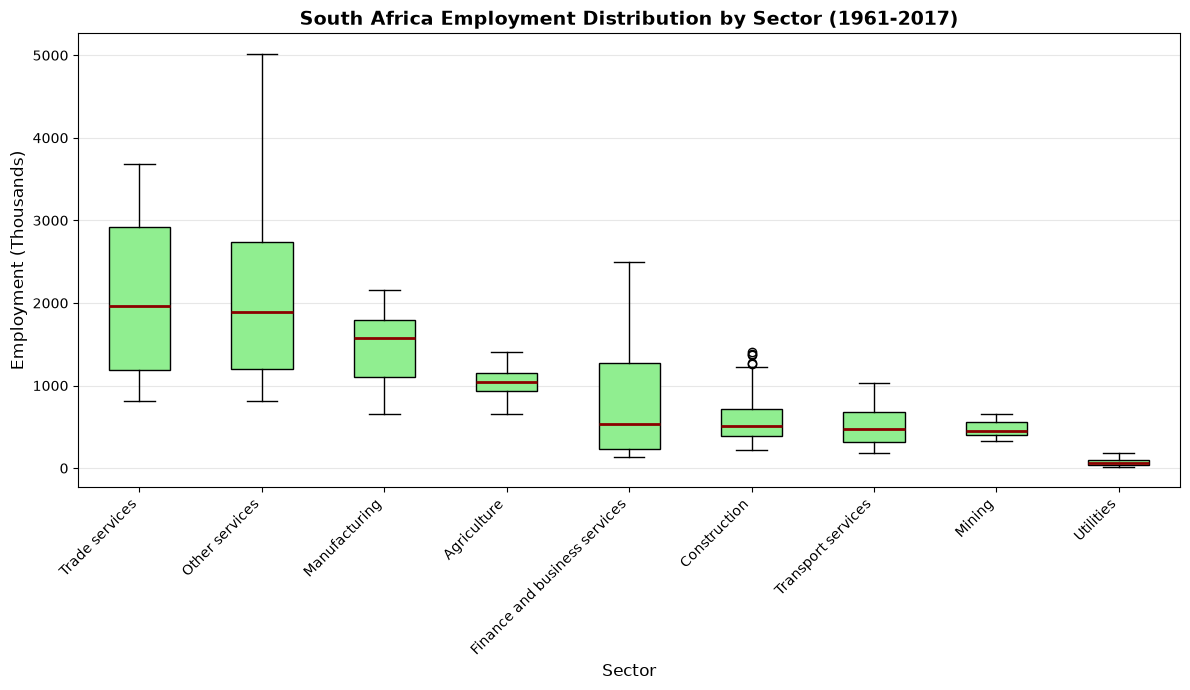

 Box plot saved as 'box_sectors_sa.png'


In [60]:
 # BOX PLOT - Employment Distribution by Sector (South Africa)

df_all_sectors = df[df['Sector'] != 'Sector: Total'].copy()
df_all_sectors['Sector_Clean'] = df_all_sectors['Sector'].str.replace('Sector: ', '')

# Order sectors by median employment for a cleaner chart
sector_order = (
    df_all_sectors.groupby('Sector_Clean')['Employment_Thousands']
    .median()
    .sort_values(ascending=False)
    .index
)

data_by_sector = [
    df_all_sectors[df_all_sectors['Sector_Clean'] == sector]['Employment_Thousands']
    for sector in sector_order
]

plt.figure(figsize=(12, 7))

plt.boxplot(data_by_sector, tick_labels=sector_order, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='black'),
            medianprops=dict(color='darkred', linewidth=2))

plt.title('South Africa Employment Distribution by Sector (1961-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Sector', fontsize=12)
plt.ylabel('Employment (Thousands)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('box_sectors_sa.png', dpi=300)
plt.show()

print(" Box plot saved as 'box_sectors_sa.png'")


### Employment Distribution by Sector
A box plot was used to compare the full spread of employment values within each sector across all years, rather than just a single year. This chart clearly shows that Trade Services and Other Services not only have the highest typical (median) employment levels but also the widest spread, reflecting substantial growth in these sectors over time. In contrast, Utilities shows almost no spread and sits close to zero throughout, while Construction shows a couple of individual outlier years that fall notably outside its usual range.




## Summary and  Key Findings

South Africa's GDP growth between 1961 and 2017 averaged around 3.02% per year, with a median of 3.10%, showing that growth has generally been positive and relatively moderate rather than extreme. The strongest year of growth was 1964, at 7.94%, while the weakest was 1992, at -2.14%. The histogram supports this pattern, showing that most years cluster in the 2-5% growth range, with only a small number of years falling into negative or unusually high territory. This suggests that although the South African economy has experienced periods of volatility, sustained deep contractions have been relatively rare over this period.

Employment tells a different story to GDP growth. Rather than being spread evenly across the economy, employment is heavily concentrated in a small number of sectors: Other Services and Trade Services together account for more than half of all employment (30.3% and 20.0% respectively), while Utilities and Mining together make up under 4%. The box plot reinforces this, showing that Trade Services and Other Services have both the highest median employment and the widest range of values over time, meaning these sectors have grown the most and the most consistently, while smaller sectors like Utilities have remained small and stable throughout the entire period.

When GDP growth and employment are compared directly in the scatter plot, a weak negative relationship can be seen, and this is confirmed numerically by a correlation coefficient of -0.30. This indicates that years with higher GDP growth were mildly associated with lower national employment, though the relationship is far from strong. This suggests that GDP growth is not a strong direct predictor of employment levels, and that other longer-term, sector-specific structural factors — such as the ongoing growth of the services sector — likely play a larger role.

Taken together, these visualisations tell a consistent story: South Africa's GDP growth has fluctuated moderately over the decades without any extreme long-term collapse, while employment has followed its own steadier, upward path shaped primarily by which sectors are largest, rather than by year-to-year economic performance. This is an important insight for the group's overall analysis, as it suggests that policies aimed purely at boosting short-term GDP growth may not be sufficient on their own to directly grow employment, and that sector-level factors deserve closer attention.
